--- HASIL PREDIKSI INDEKS KEKERINGAN ---
Input Tersimpan     : [0.8, 0.3, 0.1, 0.9, 0.6]
Output Mamdani      : 63.68 (Skala 0-100)
Output Sugeno       : 68.46 (Skala 0-100)
Selisih Output      : 4.78


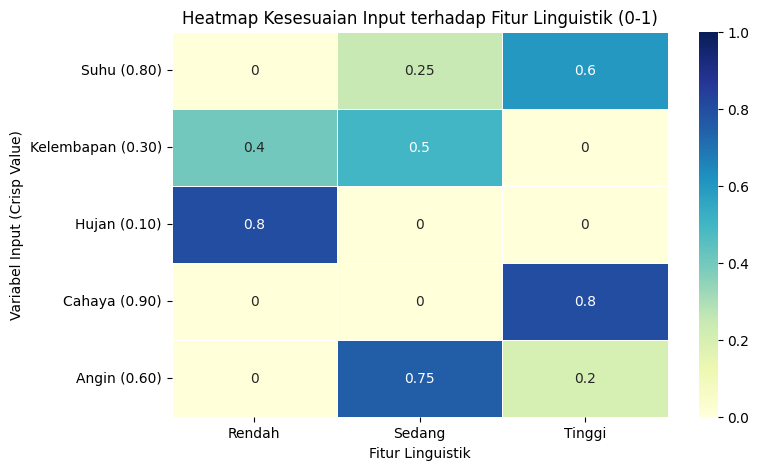

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class FuzzyKekeringan:
    def __init__(self):
        # Rentang semesta pembicaraan (Universe of Discourse) untuk Input (0-1) dan Output (0-100)
        self.x_range = np.linspace(0, 1, 100)
        self.y_range = np.linspace(0, 100, 100)
        
    # 1. FUNGSI KEANGGOTAAN (Triangular Membership Function / Kurva Segitiga)
    def trimf(self, x, abc):
        a, b, c = abc
        # Menangani array (untuk universe) atau nilai skalar (crisp input)
        if isinstance(x, np.ndarray):
            y = np.zeros_like(x)
            y = np.where((x > a) & (x <= b), (x - a) / (b - a), y)
            y = np.where((x > b) & (x < c), (c - x) / (c - b), y)
            return y
        else:
            if x <= a or x >= c: return 0.0
            elif a < x <= b: return (x - a) / (b - a)
            elif b < x < c: return (c - x) / (c - b)
            return 0.0

    # 2. FUZZIFIKASI (Menghitung derajat keanggotaan setiap input)
    def fuzzify(self, crisp_inputs):
        suhu, kelembapan, hujan, cahaya, angin = crisp_inputs
        
        # Parameter kurva segitiga (Rendah, Sedang, Tinggi) rentang 0-1
        params = {
            'Rendah': [-0.5, 0.0, 0.5],
            'Sedang': [0.1, 0.5, 0.9],
            'Tinggi': [0.5, 1.0, 1.5]
        }
        
        fuzzy_vals = {
            'Suhu': {k: self.trimf(suhu, v) for k, v in params.items()},
            'Kelembapan': {k: self.trimf(kelembapan, v) for k, v in params.items()},
            'Hujan': {k: self.trimf(hujan, v) for k, v in params.items()},
            'Cahaya': {k: self.trimf(cahaya, v) for k, v in params.items()},
            'Angin': {k: self.trimf(angin, v) for k, v in params.items()}
        }
        return fuzzy_vals

    # 3. RULE BASE & INFERENSI (Minimal 15 Rule sesuai ketentuan)
    def evaluate_rules(self, f_vals):
        rules = []
        
        # Rule 1-5 (Kondisi Ekstrem Kering)
        rules.append(('Tinggi', min(f_vals['Suhu']['Tinggi'], f_vals['Hujan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Cahaya']['Tinggi'], f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Suhu']['Tinggi'], f_vals['Angin']['Tinggi'])))
        rules.append(('Tinggi', min(f_vals['Hujan']['Rendah'], f_vals['Kelembapan']['Rendah'])))
        rules.append(('Tinggi', min(f_vals['Cahaya']['Tinggi'], f_vals['Hujan']['Rendah'])))
        
        # Rule 6-10 (Kondisi Sedang/Normal)
        rules.append(('Sedang', min(f_vals['Suhu']['Sedang'], f_vals['Hujan']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Kelembapan']['Sedang'], f_vals['Angin']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Cahaya']['Sedang'], f_vals['Suhu']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Hujan']['Sedang'], f_vals['Kelembapan']['Sedang'])))
        rules.append(('Sedang', min(f_vals['Angin']['Sedang'], f_vals['Cahaya']['Sedang'])))
        
        # Rule 11-15 (Kondisi Basah / Tidak Kering)
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'], f_vals['Suhu']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Kelembapan']['Tinggi'], f_vals['Cahaya']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'], f_vals['Angin']['Rendah'])))
        rules.append(('Rendah', min(f_vals['Suhu']['Rendah'], f_vals['Kelembapan']['Tinggi'])))
        rules.append(('Rendah', min(f_vals['Hujan']['Tinggi'], f_vals['Cahaya']['Rendah'])))

        # Agregasi (Max) untuk setiap kelas output
        agg = {'Rendah': 0, 'Sedang': 0, 'Tinggi': 0}
        for label, val in rules:
            if val > agg[label]:
                agg[label] = val
                
        return agg

    # 4a. DEFUZZIFIKASI MAMDANI (Metode Centroid / Center of Area)
    def defuzzify_mamdani(self, agg):
        # Parameter output Mamdani (0-100)
        out_params = {
            'Rendah': [-50, 0, 50],
            'Sedang': [10, 50, 90],
            'Tinggi': [50, 100, 150]
        }
        
        numerator = 0
        denominator = 0
        
        # Menghitung titik diskrit pada semesta pembicaraan output
        for y in self.y_range:
            # Komposisi antar rule menggunakan MAX
            mu_y = max(
                min(agg['Rendah'], self.trimf(y, out_params['Rendah'])),
                min(agg['Sedang'], self.trimf(y, out_params['Sedang'])),
                min(agg['Tinggi'], self.trimf(y, out_params['Tinggi']))
            )
            numerator += y * mu_y
            denominator += mu_y
            
        return numerator / denominator if denominator != 0 else 0

    # 4b. DEFUZZIFIKASI SUGENO (Metode Weighted Average / Zero-Order)
    def defuzzify_sugeno(self, agg):
        # Konstanta output Sugeno (Singleton)
        sugeno_const = {'Rendah': 20, 'Sedang': 50, 'Tinggi': 80}
        
        numerator = 0
        denominator = 0
        
        for label in ['Rendah', 'Sedang', 'Tinggi']:
            numerator += agg[label] * sugeno_const[label]
            denominator += agg[label]
            
        return numerator / denominator if denominator != 0 else 0

    # 5. VISUALISASI HEATMAP (Sesuai Permintaan)
    def plot_heatmap(self, f_vals, crisp_inputs):
        # Menyiapkan matriks data 5x3
        data_matrix = np.array([
            [f_vals['Suhu']['Rendah'], f_vals['Suhu']['Sedang'], f_vals['Suhu']['Tinggi']],
            [f_vals['Kelembapan']['Rendah'], f_vals['Kelembapan']['Sedang'], f_vals['Kelembapan']['Tinggi']],
            [f_vals['Hujan']['Rendah'], f_vals['Hujan']['Sedang'], f_vals['Hujan']['Tinggi']],
            [f_vals['Cahaya']['Rendah'], f_vals['Cahaya']['Sedang'], f_vals['Cahaya']['Tinggi']],
            [f_vals['Angin']['Rendah'], f_vals['Angin']['Sedang'], f_vals['Angin']['Tinggi']]
        ])
        
        labels_y = [f'Suhu ({crisp_inputs[0]:.2f})', f'Kelembapan ({crisp_inputs[1]:.2f})', 
                    f'Hujan ({crisp_inputs[2]:.2f})', f'Cahaya ({crisp_inputs[3]:.2f})', 
                    f'Angin ({crisp_inputs[4]:.2f})']
        labels_x = ['Rendah', 'Sedang', 'Tinggi']

        plt.figure(figsize=(8, 5))
        sns.heatmap(data_matrix, annot=True, cmap='YlGnBu', vmin=0, vmax=1, 
                    xticklabels=labels_x, yticklabels=labels_y, linewidths=0.5)
        
        plt.title('Heatmap Kesesuaian Input terhadap Fitur Linguistik (0-1)')
        plt.xlabel('Fitur Linguistik')
        plt.ylabel('Variabel Input (Crisp Value)')
        plt.show()

# ==========================================
# EKSEKUSI PROGRAM
# ==========================================
if __name__ == "__main__":
    fuzzy_sys = FuzzyKekeringan()
    
    # Contoh Input Data Nyata (Setelah dinormalisasi 0-1)
    # Suhu, Kelembapan, Hujan, Cahaya, Angin
    input_data = [0.8, 0.3, 0.1, 0.9, 0.6] 
    
    # Proses Fuzzifikasi
    f_vals = fuzzy_sys.fuzzify(input_data)
    
    # Proses Inferensi
    agregasi = fuzzy_sys.evaluate_rules(f_vals)
    
    # Proses Defuzzifikasi
    hasil_mamdani = fuzzy_sys.defuzzify_mamdani(agregasi)
    hasil_sugeno = fuzzy_sys.defuzzify_sugeno(agregasi)
    
    print(f"--- HASIL PREDIKSI INDEKS KEKERINGAN ---")
    print(f"Input Tersimpan     : {input_data}")
    print(f"Output Mamdani      : {hasil_mamdani:.2f} (Skala 0-100)")
    print(f"Output Sugeno       : {hasil_sugeno:.2f} (Skala 0-100)")
    print(f"Selisih Output      : {abs(hasil_mamdani - hasil_sugeno):.2f}")
    
    # Menampilkan Heatmap
    fuzzy_sys.plot_heatmap(f_vals, input_data)